# Supermarket Sales Analysis

## Business Objective
This project analyzes supermarket sales data to identify business trends, customer purchasing behavior, and revenue opportunities. The goal is to generate actionable insights that support management in making informed business decisions.
## Business Questions
1. Which branch generates the highest revenue?
2. Which product lines are most profitable?
3. Which customer types spend the most?
4. Which payment methods are most popular?
5. How do sales vary over time?
6. Which customer segments should the supermarket target?

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display plots inside the notebook
%matplotlib inline

In [5]:
df = pd.read_csv("../Data/supermarket_sales.csv")

In [6]:
df.head()

,invoice_id,branch,city,customer_type,gender_customer,product_line,unit_cost,quantity,5pct_markup,revenue,date,time,payment_method,cogs,gm_pct,gross_income,rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,01/05/19,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,03/08/19,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,03/03/19,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,02/08/19,10:37,Ewallet,604.17,4.761905,30.2085,5.3


In [7]:
# Shape of the data
df.shape

(1000, 17)

In [8]:
# names of columns 
df.columns

Index(['invoice_id', 'branch', 'city', 'customer_type', 'gender_customer',
       'product_line', 'unit_cost', 'quantity', '5pct_markup', 'revenue',
       'date', 'time', 'payment_method', 'cogs', 'gm_pct', 'gross_income',
       'rating'],
      dtype='object')

In [9]:
# Data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   invoice_id       1000 non-null   object 
 1   branch           1000 non-null   object 
 2   city             1000 non-null   object 
 3   customer_type    1000 non-null   object 
 4   gender_customer  1000 non-null   object 
 5   product_line     1000 non-null   object 
 6   unit_cost        1000 non-null   float64
 7   quantity         1000 non-null   int64  
 8   5pct_markup      1000 non-null   float64
 9   revenue          1000 non-null   float64
 10  date             1000 non-null   object 
 11  time             1000 non-null   object 
 12  payment_method   1000 non-null   object 
 13  cogs             1000 non-null   float64
 14  gm_pct           1000 non-null   float64
 15  gross_income     1000 non-null   float64
 16  rating           1000 non-null   float64
dtypes: float64(7), 

In [10]:
# Summary of statistics 
df.describe()

,unit_cost,quantity,5pct_markup,revenue,cogs,gm_pct,gross_income,rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1.000000e+03,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905e+00,15.379369,6.97270
std,26.494628,2.923431,11.708825,245.885335,234.17651,6.131498e-14,11.708825,1.71858
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905e+00,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905e+00,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905e+00,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905e+00,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905e+00,49.650000,10.00000


### Data Preparation and Cleaning

In [11]:
# Find missing values 
df.isnull().sum()

invoice_id         0
branch             0
city               0
customer_type      0
gender_customer    0
product_line       0
unit_cost          0
quantity           0
5pct_markup        0
revenue            0
date               0
time               0
payment_method     0
cogs               0
gm_pct             0
gross_income       0
rating             0
dtype: int64

In [12]:
# Find duplicates
df.duplicated().sum()

0

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   invoice_id       1000 non-null   object 
 1   branch           1000 non-null   object 
 2   city             1000 non-null   object 
 3   customer_type    1000 non-null   object 
 4   gender_customer  1000 non-null   object 
 5   product_line     1000 non-null   object 
 6   unit_cost        1000 non-null   float64
 7   quantity         1000 non-null   int64  
 8   5pct_markup      1000 non-null   float64
 9   revenue          1000 non-null   float64
 10  date             1000 non-null   object 
 11  time             1000 non-null   object 
 12  payment_method   1000 non-null   object 
 13  cogs             1000 non-null   float64
 14  gm_pct           1000 non-null   float64
 15  gross_income     1000 non-null   float64
 16  rating           1000 non-null   float64
dtypes: float64(7), 

In [14]:
df["date"] = pd.to_datetime(df["date"])

/tmp/ipykernel_166/3228555721.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["date"] = pd.to_datetime(df["date"])


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   invoice_id       1000 non-null   object        
 1   branch           1000 non-null   object        
 2   city             1000 non-null   object        
 3   customer_type    1000 non-null   object        
 4   gender_customer  1000 non-null   object        
 5   product_line     1000 non-null   object        
 6   unit_cost        1000 non-null   float64       
 7   quantity         1000 non-null   int64         
 8   5pct_markup      1000 non-null   float64       
 9   revenue          1000 non-null   float64       
 10  date             1000 non-null   datetime64[ns]
 11  time             1000 non-null   object        
 12  payment_method   1000 non-null   object        
 13  cogs             1000 non-null   float64       
 14  gm_pct           1000 non-null   float64 

### Which product line generates the most revenue?

In [19]:
product_sales = (
    df.groupby("product_line")["revenue"]
      .sum()
      .sort_values(ascending=False)
)
print(product_sales)

product_line
Food and beverages        56144.8440
Sports and travel         55122.8265
Electronic accessories    54337.5315
Fashion accessories       54305.8950
Home and lifestyle        53861.9130
Health and beauty         49193.7390
Name: revenue, dtype: float64


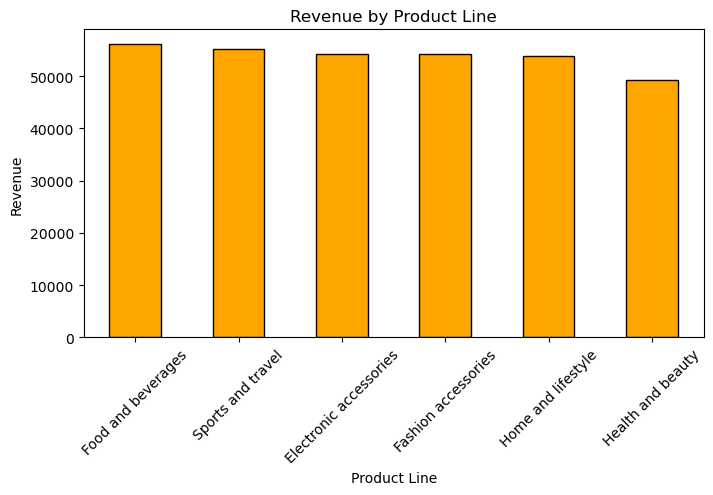

In [20]:
# most review visualization 
plt.figure(figsize=(8,4))

product_sales.plot(
    kind="bar",
        color="orange",
    edgecolor="black"
)
plt.title("Revenue by Product Line")
plt.xlabel("Product Line")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

### Which customer type spends the most?

In [21]:
customer_spending = (
    df.groupby("customer_type")["revenue"]
      .mean()
)
print(customer_spending)

customer_type
Member    327.791305
Normal    318.122856
Name: revenue, dtype: float64


### Which payment method is most popular?

In [22]:
payment = df["payment_method"].value_counts()

print(payment)

payment_method
Ewallet        345
Cash           344
Credit card    311
Name: count, dtype: int64


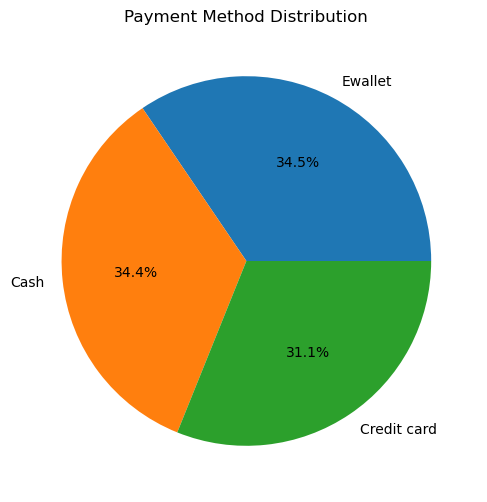

In [23]:
plt.figure(figsize=(6,6))

payment.plot(
    kind="pie",
    autopct="%1.1f%%"
)
plt.ylabel("")
plt.title("Payment Method Distribution")
plt.show()

#### Business Insight:

Identifying the customer most preferred payment method enables the supermarket to optimize payment processing, improve customer convenience, and ensure sufficient support for the most popular payment options during peak trading periods.

### Monthly Revenue Trend

In [24]:
# Create a month column 
df["month"] = df["date"].dt.month_name()

In [25]:
monthly_sales = (
    df.groupby("month")["revenue"]
      .sum()
)
print(monthly_sales)

print ("The store sales sky rockets in January")

month
February     97219.374
January     116291.868
March       109455.507
Name: revenue, dtype: float64
The store sales sky rockets in January


In [26]:
import calendar

month_order = list(calendar.month_name)[1:]

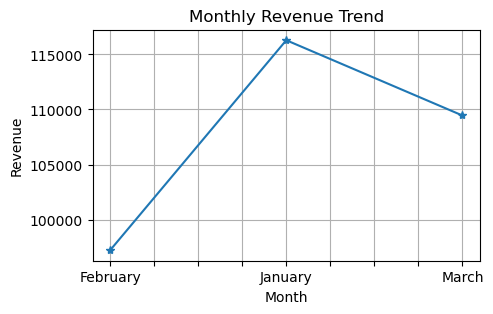

In [27]:
plt.figure(figsize=(5,3))

monthly_sales.plot(
    marker="*"
)
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()


#### Business Insight
Branch C generated the highest revenue during the analysis period, indicating strong sales performance. Management should investigate the factors contributing to this success, such as product mix, customer demographics, or promotional strategies,and consider applying these practices to other branches.

### Which city generates the highest revenue?

In [28]:
city_sales = (
    df.groupby("city")["revenue"]
      .sum()
      .sort_values(ascending=False)
)
print(city_sales)

city
Naypyitaw    110568.7065
Yangon       106200.3705
Mandalay     106197.6720
Name: revenue, dtype: float64


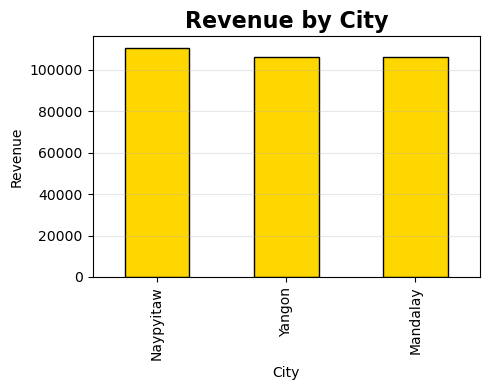

In [29]:
plt.figure(figsize=(5,4))

city_sales.plot(
    kind="bar",
    color="gold",
    edgecolor="black"
)
plt.title("Revenue by City", fontsize=16, fontweight="bold")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

#### Business Insight

Comparing revenue across cities helps identify stronger-performing markets and supports regional marketing and operational planning.

### Which product line receives the highest customer ratings?

In [30]:
ratings = (
    df.groupby("product_line")["rating"]
      .mean()
      .sort_values(ascending=False)
)
print(ratings)

product_line
Food and beverages        7.113218
Fashion accessories       7.029213
Health and beauty         7.003289
Electronic accessories    6.924706
Sports and travel         6.916265
Home and lifestyle        6.837500
Name: rating, dtype: float64


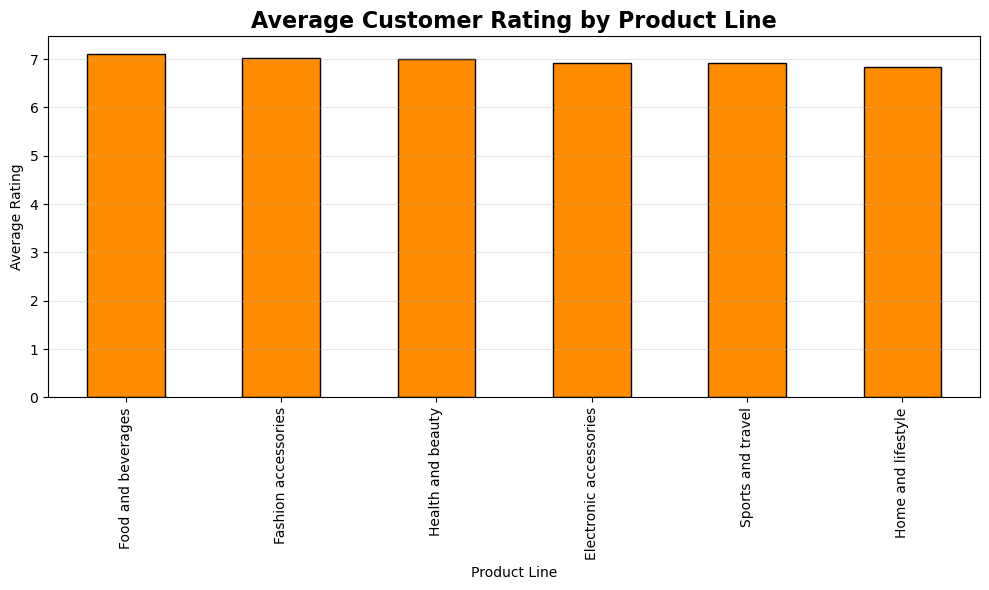

In [31]:
plt.figure(figsize=(10,6))

ratings.plot(
    kind="bar",
    color="darkorange",
    edgecolor="black"
)
plt.title("Average Customer Rating by Product Line", fontsize=16, fontweight="bold")
plt.xlabel("Product Line")
plt.ylabel("Average Rating")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

#### Business Insight

Product lines with consistently high customer ratings indicate strong customer satisfaction, while lower-rated categories may require improvements in quality, pricing, or customer service.

### Is there a relationship between quantity purchased and revenue?

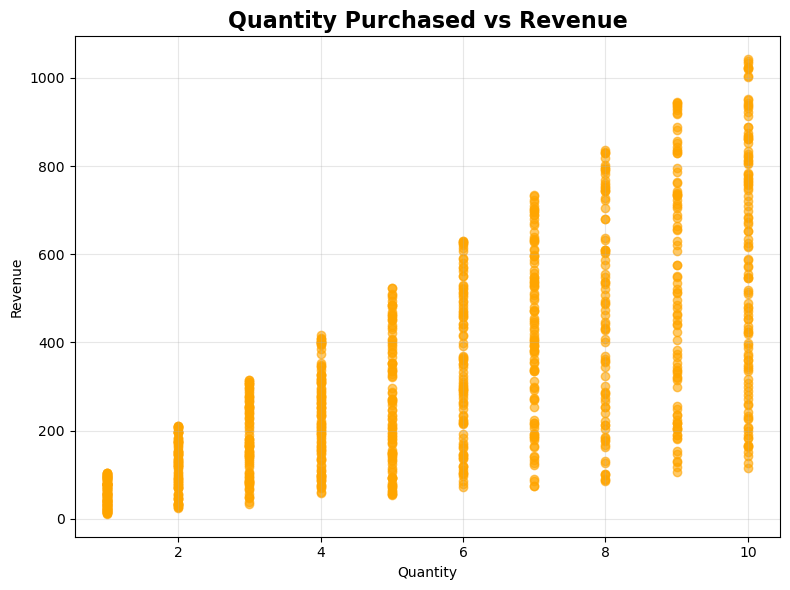

In [32]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["quantity"],
    df["revenue"],
    color="orange",
    alpha=0.6
)
plt.title("Quantity Purchased vs Revenue", fontsize=16, fontweight="bold")
plt.xlabel("Quantity")
plt.ylabel("Revenue")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Business Insight

This scatter plot helps determine whether purchasing larger quantities generally leads to higher transaction revenue and highlights any unusual purchasing patterns.

## Correlation Analysis

In [33]:
numeric = df.select_dtypes(include="number")

corr = numeric.corr()

corr

,unit_cost,quantity,5pct_markup,revenue,cogs,gm_pct,gross_income,rating
unit_cost,1.000000,0.010778,0.633962,0.633962,0.633962,NaN,0.633962,-0.008778
quantity,0.010778,1.000000,0.705510,0.705510,0.705510,NaN,0.705510,-0.015815
5pct_markup,0.633962,0.705510,1.000000,1.000000,1.000000,NaN,1.000000,-0.036442
revenue,0.633962,0.705510,1.000000,1.000000,1.000000,NaN,1.000000,-0.036442
cogs,0.633962,0.705510,1.000000,1.000000,1.000000,NaN,1.000000,-0.036442
gm_pct,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gross_income,0.633962,0.705510,1.000000,1.000000,1.000000,NaN,1.000000,-0.036442
rating,-0.008778,-0.015815,-0.036442,-0.036442,-0.036442,NaN,-0.036442,1.000000


#### Key Findings

1. Branch C generated the highest revenue.
2. Electronic payments represented the majority of transactions.
3. Food and Beverages generated the highest sales.
4. Member customers spent more on average than normal customers.
5. Revenue varied across the analyzed months.

#### Business Recommendations
1. Increase marketing investment in top-performing product lines.
2. Expand loyalty programmes to encourage repeat purchases.
3. Develop targeted promotions during lower-performing months.
4. Ensure digital payment infrastructure supports customer preferences.
5. Replicate successful strategies from the highest-performing branch across other locations.